[*********************100%***********************]  1 of 1 completed
C:\Users\diwan\Downloads\.env\Lib\site-packages\scipy\optimize\_minimize.py:726: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 1631.724159
         Iterations: 4
         Function evaluations: 337
         Gradient evaluations: 66
Root Mean Square Error (RMSE): 4.78


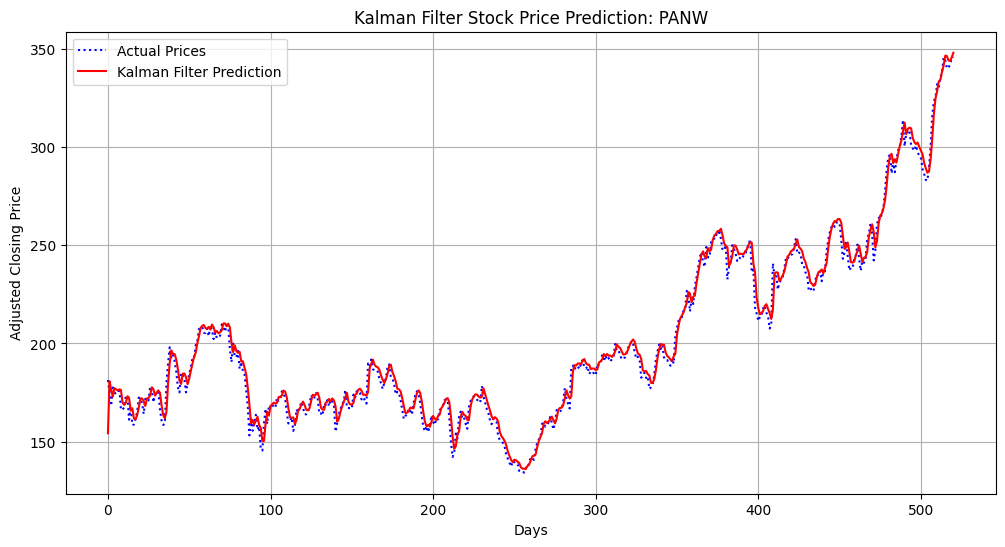

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from datetime import datetime
import matplotlib.pyplot as plt
import yfinance as yf

# Kalman Filter function to calculate log likelihood
def kalman_filter(param, *args):
    Z = param[0]
    T = param[1]
    H = param[2]
    Q = param[3]
    Y, S = args

    # Initialize Kalman filter matrices and vectors
    u_predict, u_update, P_predict, P_update, v, F = {}, {}, {}, {}, {}, {}
    u_update[0] = Y[0]
    u_predict[0] = u_update[0]
    P_update[0] = np.var(Y) / 4
    P_predict[0] = T * P_update[0] * T + Q
    Likelihood = 0

    for s in range(1, S):
        F[s] = Z * P_predict[s - 1] * Z + H
        v[s] = Y[s - 1] - Z * u_predict[s - 1]
        u_update[s] = u_predict[s - 1] + P_predict[s - 1] * Z / F[s] * v[s]
        u_predict[s] = T * u_update[s]
        P_update[s] = P_predict[s - 1] - P_predict[s - 1] * Z / F[s] * Z * P_predict[s - 1]
        P_predict[s] = T * P_update[s] * T + Q

        # Log likelihood
        Likelihood += 0.5 * (np.log(2 * np.pi) + np.log(abs(F[s])) + v[s]**2 / F[s])

    return Likelihood

# Kalman Smoother function to smooth estimated states
def kalman_smoother(params, Y, S):
    Z = params[0]
    T = params[1]
    H = params[2]
    Q = params[3]

    u_predict, u_update, P_predict, P_update, v, F = {}, {}, {}, {}, {}, {}
    u_update[0] = Y[0]
    u_predict[0] = u_update[0]
    P_update[0] = np.var(Y) / 4
    P_predict[0] = T * P_update[0] * T + Q

    for s in range(1, S):
        F[s] = Z * P_predict[s - 1] * Z + H
        v[s] = Y[s - 1] - Z * u_predict[s - 1]
        u_update[s] = u_predict[s - 1] + P_predict[s - 1] * Z / F[s] * v[s]
        u_predict[s] = T * u_update[s]
        P_update[s] = P_predict[s - 1] - P_predict[s - 1] * Z / F[s] * Z * P_predict[s - 1]
        P_predict[s] = T * P_update[s] * T + Q

    u_smooth, P_smooth = {}, {}
    u_smooth[S - 1] = u_update[S - 1]
    P_smooth[S - 1] = P_update[S - 1]

    for t in range(S - 2, -1, -1):
        u_smooth[t] = u_update[t] + P_update[t] * T / P_predict[t + 1] * (u_smooth[t + 1] - T * u_update[t])
        P_smooth[t] = P_update[t] + P_update[t] * T / P_predict[t + 1] * (P_smooth[t + 1] - P_predict[t + 1]) / P_predict[t + 1] * T * P_update[t]

    return u_smooth

# Fetch data for Palo Alto Networks (PANW)
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 1, 31)
stock_symbol = 'PANW'
stock = yf.download(stock_symbol, start=start_date, end=end_date)
Y = stock['Adj Close'].values
S = Y.shape[0]

# Tuning Initial parameter guess based on empirical values
param0 = np.array([1.1, 0.9, np.var(Y) / 100, np.var(Y) / 100])

# Estimate parameters by minimizing the likelihood function with stricter tolerance
results = minimize(kalman_filter, param0, args=(Y, S), method='BFGS', tol=1e-4, options={'disp': True})
param_star = results.x

# Smooth estimated path with optimal parameters
path = kalman_smoother(param_star, Y, S)
sorted_path = dict(sorted(path.items()))
Y_kalmanFilter = list(sorted_path.values())

# Calculate RMSE
RMSE = np.sqrt(np.mean((np.array(Y_kalmanFilter) - np.array(Y))**2))
print(f'Root Mean Square Error (RMSE): {RMSE:.2f}')

# Visualization
timevec = np.arange(S)
plt.figure(figsize=(12, 6))
plt.plot(timevec, Y, label='Actual Prices', color='blue', linestyle=':')
plt.plot(timevec, Y_kalmanFilter, label='Kalman Filter Prediction', color='red')
plt.title(f'Kalman Filter Stock Price Prediction: {stock_symbol}')
plt.xlabel('Days')
plt.ylabel('Adjusted Closing Price')
plt.legend()
plt.grid()
plt.show()
